# Spending Forecasting — Clean, Leakage-Free Version

This notebook rebuilds the original forecasting pipeline with a stricter time-series setup.

### Main fixes
- No centered/forward-looking target.
- The outlier cap is learned from the **training period only**.
- The test set is never used for model/hyperparameter selection.
- The target is a **future-only 7-day average spending level** by default.
- Lag and rolling features use only information available at the forecast date.
- Ridge/Lasso are scaled with `StandardScaler`.
- Calendar variables use cyclical encoding.
- Models are selected using time-series cross-validation on the training period.
- The final test set is evaluated only once after the model is selected.

> **Important:** This notebook is designed to improve the *quality and validity* of the R², not to artificially maximize it. A leakage-free R² may be lower than the original 0.55, and that would be a more trustworthy result.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

RANDOM_STATE = 42

DATA_PATH = Path(
    r"D:\clg_project\AI-Financial-Wellness-Coach\data\processed\forecasting_features.csv"
)
OUT = Path(r"D:\clg_project\AI-Financial-Wellness-Coach\data\processed")
MODEL_DIR = Path(r"D:\clg_project\AI-Financial-Wellness-Coach\src\models")
PLOT_DIR = Path(r"D:\clg_project\AI-Financial-Wellness-Coach\src\Forecating\plots")

OUT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Load and inspect the transaction data

The original notebook starts from transaction-level data. We keep the chronological order because this is a forecasting problem.

In [2]:
df = pd.read_csv(DATA_PATH)
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df = df.sort_values("transaction_date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["transaction_date"].min(), "to", df["transaction_date"].max())
display(df.head())

Shape: (7000, 9)
Date range: 2018-01-01 00:00:00 to 2019-11-10 00:00:00


,transaction_date,amount,day,week,month,weekend,month_end,salary_week,festival_season
0,2018-01-01,4361.84,1,1,1,0,0,1,0
1,2018-01-01,20861.36,1,1,1,0,0,1,0
2,2018-01-01,39289.29,1,1,1,0,0,1,0
3,2018-01-01,116.00,1,1,1,0,0,1,0
4,2018-01-01,1722.01,1,1,1,0,0,1,0


## 2. Create chronological train / validation / test periods

We split by **date**, not by random rows.

- Train: 70%
- Validation: 15%
- Test: 15%

The test period remains completely untouched until final evaluation.

In [3]:
unique_dates = np.sort(df["transaction_date"].dt.normalize().unique())

n_dates = len(unique_dates)
train_date_end = unique_dates[int(n_dates * 0.70) - 1]
val_date_end = unique_dates[int(n_dates * 0.85) - 1]

print("Train ends:", train_date_end)
print("Validation ends:", val_date_end)
print("Test starts:", val_date_end + np.timedelta64(1, "D"))

Train ends: 2019-04-02T00:00:00.000000000
Validation ends: 2019-07-09T00:00:00.000000000
Test starts: 2019-07-10T00:00:00.000000000


## 3. Winsorize using training data only

The original notebook calculated the 95th percentile using the complete dataset. That allows future/test information to influence preprocessing.

Here the cap is learned only from transactions in the training period and then applied unchanged to validation and test.

In [4]:
train_transactions = df[df["transaction_date"].dt.normalize() <= pd.Timestamp(train_date_end)]

CAP_PCT = 0.95
cap_value = train_transactions["amount"].quantile(CAP_PCT)

df["amount_capped"] = df["amount"].clip(upper=cap_value)

print(f"Training-only {CAP_PCT:.0%} cap: ₹{cap_value:,.2f}")
print(
    "Original skew:", round(df["amount"].skew(), 2),
    "| Capped skew:", round(df["amount_capped"].skew(), 2)
)

Training-only 95% cap: ₹21,799.60
Original skew: 8.37 | Capped skew: 2.38


## 4. Aggregate transactions to daily spending

For forecasting we use the winsorized amount. Weekly and monthly raw totals are retained separately for reporting.

In [5]:
daily_spending = (
    df.groupby(df["transaction_date"].dt.normalize())["amount_capped"]
      .sum()
      .rename("total_spending")
      .reset_index()
      .rename(columns={"transaction_date": "date"})
      .sort_values("date")
      .reset_index(drop=True)
)

weekly_spending = (
    df.set_index("transaction_date")["amount"]
      .resample("W")
      .sum()
      .reset_index()
      .rename(columns={"transaction_date": "date", "amount": "total_spending"})
)

monthly_spending = (
    df.set_index("transaction_date")["amount"]
      .resample("ME")
      .sum()
      .reset_index()
      .rename(columns={"transaction_date": "date", "amount": "total_spending"})
)

print("Daily:", daily_spending.shape)
print("Weekly:", weekly_spending.shape)
print("Monthly:", monthly_spending.shape)

daily_spending.to_csv(OUT / "daily_spending.csv", index=False)
weekly_spending.to_csv(OUT / "weekly_spending.csv", index=False)
monthly_spending.to_csv(OUT / "monthly_spending.csv", index=False)

Daily: (653, 2)
Weekly: (97, 2)
Monthly: (23, 2)


## 5. Handle missing calendar dates

A missing date is treated as a zero-transaction day **only if the source dataset represents the complete transaction history**.

If missing dates mean missing data rather than no transactions, this step should be changed.

In [6]:
full_dates = pd.date_range(
    daily_spending["date"].min(),
    daily_spending["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(daily_spending["date"])

print("Missing calendar dates:", len(missing_dates))

daily_spending = (
    daily_spending.set_index("date")
    .reindex(full_dates, fill_value=0)
    .rename_axis("date")
    .reset_index()
)

print("Daily rows after calendar completion:", len(daily_spending))

Missing calendar dates: 26
Daily rows after calendar completion: 679


## 6. Visualize the daily spending series

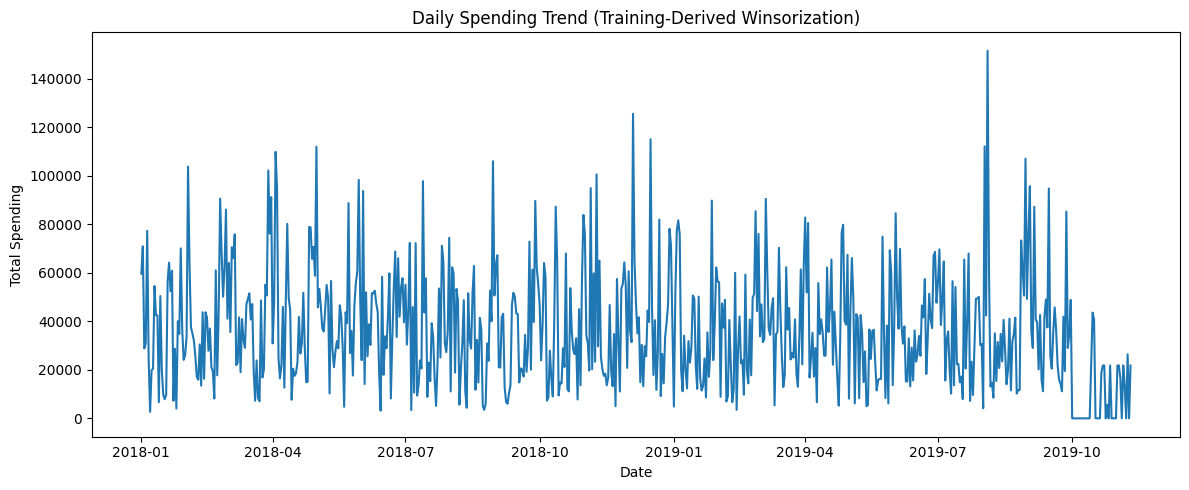

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(daily_spending["date"], daily_spending["total_spending"])
plt.title("Daily Spending Trend (Training-Derived Winsorization)")
plt.xlabel("Date")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.savefig(PLOT_DIR / "daily_trend_clean.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Build leakage-free forecasting features

Every lag and rolling feature is based on **past spending only**.

The `shift(1)` is critical: it prevents the current day's spending from entering its own predictors.

In [8]:
d = daily_spending.copy()

d["day_of_week"] = d["date"].dt.dayofweek
d["day"] = d["date"].dt.day
d["week"] = d["date"].dt.isocalendar().week.astype(int)
d["month"] = d["date"].dt.month
d["quarter"] = d["date"].dt.quarter
d["year"] = d["date"].dt.year
d["is_weekend"] = (d["day_of_week"] >= 5).astype(int)
d["is_month_end"] = d["date"].dt.is_month_end.astype(int)

# Past-only lag features
d["lag_1"] = d["total_spending"].shift(1)
d["lag_2"] = d["total_spending"].shift(2)
d["lag_3"] = d["total_spending"].shift(3)
d["lag_7"] = d["total_spending"].shift(7)
d["lag_14"] = d["total_spending"].shift(14)
d["lag_30"] = d["total_spending"].shift(30)

past = d["total_spending"].shift(1)

d["rolling_mean_3"] = past.rolling(3).mean()
d["rolling_mean_7"] = past.rolling(7).mean()
d["rolling_mean_14"] = past.rolling(14).mean()
d["rolling_mean_30"] = past.rolling(30).mean()

d["rolling_std_7"] = past.rolling(7).std()
d["rolling_std_14"] = past.rolling(14).std()
d["rolling_std_30"] = past.rolling(30).std()

# Exponentially weighted past average
d["ewm_7"] = past.ewm(span=7, adjust=False).mean()
d["ewm_14"] = past.ewm(span=14, adjust=False).mean()

# Cyclical calendar encoding
d["dow_sin"] = np.sin(2 * np.pi * d["day_of_week"] / 7)
d["dow_cos"] = np.cos(2 * np.pi * d["day_of_week"] / 7)

d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)

print(d.shape)
display(d.head())

(679, 29)


,date,total_spending,day_of_week,day,week,month,quarter,year,is_weekend,is_month_end,...,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_std_30,ewm_7,ewm_14,dow_sin,dow_cos,month_sin,month_cos
0,2018-01-01,59613.5915,0,1,1,1,1,2018,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.5,0.866025
1,2018-01-02,70918.5630,1,2,1,1,1,2018,0,0,...,NaN,NaN,NaN,NaN,59613.591500,59613.591500,0.781831,0.623490,0.5,0.866025
2,2018-01-03,28836.1200,2,3,1,1,1,2018,0,0,...,NaN,NaN,NaN,NaN,62439.834375,61120.921033,0.974928,-0.222521,0.5,0.866025
3,2018-01-04,30800.5315,3,4,1,1,1,2018,0,0,...,NaN,NaN,NaN,NaN,54038.905781,56816.280896,0.433884,-0.900969,0.5,0.866025
4,2018-01-05,77277.5330,4,5,1,1,1,2018,0,0,...,NaN,NaN,NaN,NaN,48229.312211,53347.514309,-0.433884,-0.900969,0.5,0.866025


## 8. Define a genuine future-only target

### Default horizon = 7 days

The target is the **average spending over the next 7 days**:

`t+1, t+2, ..., t+7`

Unlike the old centered target, no future value is used to construct today's features.

This also gives the project a useful business interpretation:

> "How much am I expected to spend per day, on average, over the next 7 days?"

In [9]:
FORECAST_HORIZON = 7

future_values = pd.concat(
    [d["total_spending"].shift(-i) for i in range(1, FORECAST_HORIZON + 1)],
    axis=1
)

d["target"] = future_values.mean(axis=1, skipna=False)

# Remove rows where either the past feature window or future target is unavailable.
d = d.dropna().reset_index(drop=True)

print("Final modeling shape:", d.shape)
display(d[["date", "total_spending", "target"]].head(10))

Final modeling shape: (642, 30)


,date,total_spending,target
0,2018-01-31,25999.9200,47291.288214
1,2018-02-01,33660.4700,44913.466786
2,2018-02-02,103766.4845,32367.647571
3,2018-02-03,63395.9030,27667.222857
4,2018-02-04,37489.4000,24238.044286
5,2018-02-05,34977.3200,25489.315929
6,2018-02-06,32099.6100,23231.617357
7,2018-02-07,25649.8300,25814.849000
8,2018-02-08,17015.7200,29303.924929
9,2018-02-09,15945.7500,31008.273714


## 9. Verify that the target is truly future-only

For a given date, the target must contain spending from future dates only.

In [10]:
check_date = d.loc[100, "date"]
check_row = d.loc[100]

future_dates = pd.date_range(
    check_date + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq="D"
)

print("Forecast date:", check_date.date())
print("Future dates used by target:", future_dates[0].date(), "to", future_dates[-1].date())
print("Target:", round(check_row["target"], 2))

Forecast date: 2018-05-11
Future dates used by target: 2018-05-12 to 2018-05-18
Target: 32358.19


## 10. Chronological train / validation / test split

The final test period is kept untouched.

The validation set is used to compare model families after time-series cross-validation has been performed on the training set.

In [11]:
n = len(d)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = d.iloc[:train_end].copy()
validation = d.iloc[train_end:val_end].copy()
test = d.iloc[val_end:].copy()

print("Train:", train.shape, train["date"].min(), "to", train["date"].max())
print("Validation:", validation.shape, validation["date"].min(), "to", validation["date"].max())
print("Test:", test.shape, test["date"].min(), "to", test["date"].max())

Train: (449, 30) 2018-01-31 00:00:00 to 2019-04-24 00:00:00
Validation: (96, 30) 2019-04-25 00:00:00 to 2019-07-29 00:00:00
Test: (97, 30) 2019-07-30 00:00:00 to 2019-11-03 00:00:00


## 11. Feature list and metrics

In [12]:
features = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_30",
    "rolling_mean_3", "rolling_mean_7", "rolling_mean_14", "rolling_mean_30",
    "rolling_std_7", "rolling_std_14", "rolling_std_30",
    "ewm_7", "ewm_14",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "day", "week", "month", "quarter",
    "is_weekend", "is_month_end"
]

target = "target"

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom else np.nan

## 12. Strong baseline models

We compare ML models against simple forecasting baselines.

The most important baseline is the previous 7-day average.

In [13]:
baseline_val_pred = validation["rolling_mean_7"].values
baseline_test_pred = test["rolling_mean_7"].values

baseline_val = evaluate(y_val, baseline_val_pred)
baseline_test = evaluate(y_test, baseline_test_pred)

print("Baseline — Validation:", baseline_val)
print("Baseline — Test:", baseline_test)

Baseline — Validation: {'MAE': 12104.17838392855, 'RMSE': np.float64(14272.171525943408), 'R2': -0.9695427653158946}
Baseline — Test: {'MAE': 14904.496046391721, 'RMSE': np.float64(19214.489648864463), 'R2': -0.14165135131157736}


## 13. Time-series cross-validation

No random K-fold is used. Each validation fold is strictly later in time than its training fold.

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

## 14. Candidate models

Ridge and Lasso are placed inside pipelines with scaling.

Tree models do not require scaling.

In [15]:
models = {
    "Ridge": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        {
            "model__alpha": np.logspace(-3, 3, 20)
        }
    ),

    "Lasso": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(max_iter=30000))
        ]),
        {
            "model__alpha": np.logspace(-3, 2, 15)
        }
    ),

    "Random Forest": (
        RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "n_estimators": [200, 400, 600],
            "max_depth": [5, 8, 12, 16, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": [0.6, 0.8, 1.0]
        }
    ),

    "XGBoost": (
        XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "n_estimators": [200, 400, 600, 800],
            "learning_rate": [0.01, 0.03, 0.05, 0.08],
            "max_depth": [2, 3, 4, 5],
            "min_child_weight": [1, 3, 5, 8],
            "subsample": [0.7, 0.85, 1.0],
            "colsample_bytree": [0.7, 0.85, 1.0],
            "reg_alpha": [0, 0.01, 0.1, 1],
            "reg_lambda": [1, 3, 10]
        }
    )
}

## 15. Tune models using only the training period

The validation period and test period are not used during hyperparameter search.

In [16]:
searches = {}
cv_results = []

for name, (estimator, param_dist) in models.items():
    print(f"\nTuning {name}...")

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=25,
        scoring="r2",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train, y_train)
    searches[name] = search

    print("Best CV R2:", round(search.best_score_, 4))
    print("Best params:", search.best_params_)


Tuning Ridge...


c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=25. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CV R2: -0.1203
Best params: {'model__alpha': np.float64(483.2930238571752)}

Tuning Lasso...


c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 15 is smaller than n_iter=25. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.428e+08, tolerance: 1.529e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.365e+09, tolerance: 2.274e+06
  model = 

Best CV R2: -1.994
Best params: {'model__alpha': np.float64(100.0)}

Tuning Random Forest...


Best CV R2: 0.0774
Best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': 16}

Tuning XGBoost...
Best CV R2: 0.1415
Best params: {'subsample': 0.85, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.85}


## 16. Evaluate tuned models on validation data

Model selection happens here — **before the test set is opened**.

In [17]:
validation_results = {
    "Baseline (7-day mean)": baseline_val
}

validation_predictions = {
    "Baseline (7-day mean)": baseline_val_pred
}

for name, search in searches.items():
    pred = search.predict(X_val)
    validation_predictions[name] = pred
    validation_results[name] = evaluate(y_val, pred)

validation_df = pd.DataFrame(validation_results).T.sort_values("RMSE")
validation_df

,MAE,RMSE,R2
Ridge,7913.572533,9386.856806,0.148027
Random Forest,7979.605507,9541.235658,0.119773
XGBoost,8176.636628,9788.290005,0.073599
Lasso,8189.629359,10482.239399,-0.062413
Baseline (7-day mean),12104.178384,14272.171526,-0.969543


## 17. Select the best model using validation R²

We select the model based on validation performance, not test performance.

In [18]:
best_name = validation_df["R2"].idxmax()

if validation_df.loc[best_name, "R2"] < validation_df.loc["Baseline (7-day mean)", "R2"]:
    print("Warning: no ML model beats the baseline on validation.")
    best_name = "Baseline (7-day mean)"

print("Selected model:", best_name)

Selected model: Ridge


## 18. Refit the selected ML model on train + validation

Only after selecting the model do we use the validation data for the final training fit.

The test set remains untouched until the next cell.

In [19]:
train_full = pd.concat([train, validation], axis=0)

X_train_full = train_full[features]
y_train_full = train_full[target]

if best_name == "Baseline (7-day mean)":
    final_model = None
    test_pred = baseline_test_pred
else:
    final_model = clone(searches[best_name].best_estimator_)
    final_model.fit(X_train_full, y_train_full)
    test_pred = final_model.predict(X_test)

final_metrics = evaluate(y_test, test_pred)
final_metrics["WAPE"] = wape(y_test, test_pred)

print("FINAL TEST RESULTS")
print(pd.Series(final_metrics))

FINAL TEST RESULTS
MAE     17951.112541
RMSE    21646.940522
R2         -0.449002
WAPE       67.607993
dtype: float64


## 19. Compare final test performance with the baseline

In [20]:
final_comparison = pd.DataFrame({
    "Baseline (7-day mean)": evaluate(y_test, baseline_test_pred),
    "Selected model": evaluate(y_test, test_pred)
}).T

final_comparison["WAPE"] = [
    wape(y_test, baseline_test_pred),
    wape(y_test, test_pred)
]

final_comparison

,MAE,RMSE,R2,WAPE
Baseline (7-day mean),14904.496046,19214.489649,-0.141651,56.133739
Selected model,17951.112541,21646.940522,-0.449002,67.607993


## 20. Actual vs predicted forecast

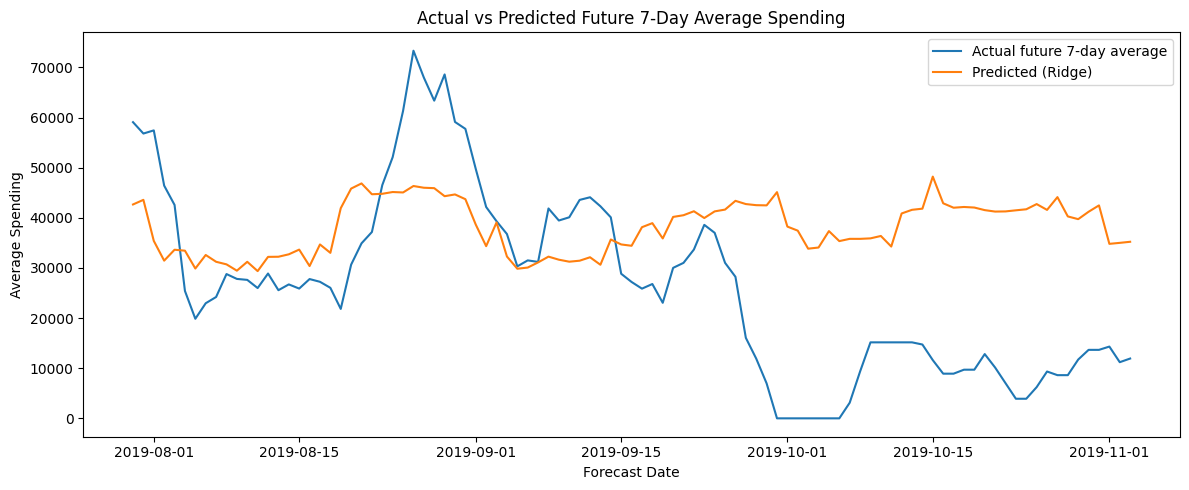

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test, label="Actual future 7-day average")
plt.plot(test["date"], test_pred, label=f"Predicted ({best_name})")

plt.title("Actual vs Predicted Future 7-Day Average Spending")
plt.xlabel("Forecast Date")
plt.ylabel("Average Spending")
plt.legend()
plt.tight_layout()

plt.savefig(PLOT_DIR / "actual_vs_predicted_clean.png", dpi=120, bbox_inches="tight")
plt.show()

## 21. Residual analysis

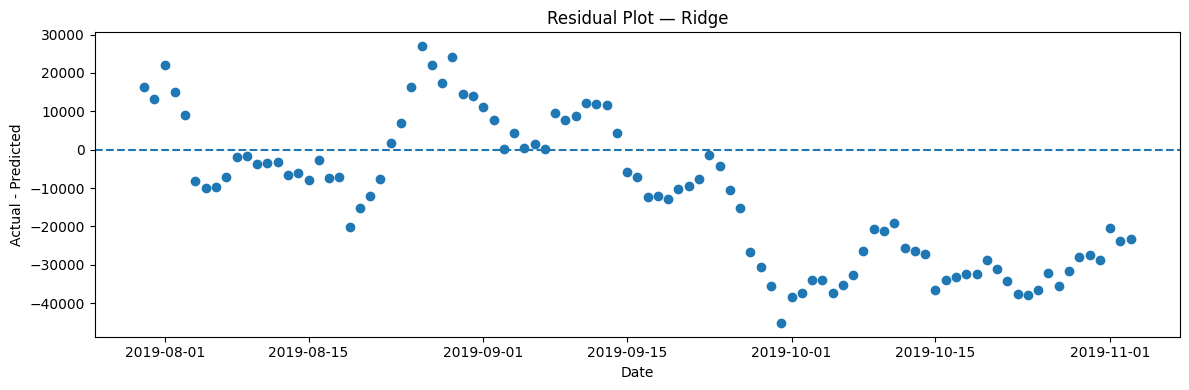

In [22]:
residuals = y_test.values - test_pred

plt.figure(figsize=(12, 4))
plt.scatter(test["date"], residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot — {best_name}")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.tight_layout()

plt.savefig(PLOT_DIR / "residuals_clean.png", dpi=120, bbox_inches="tight")
plt.show()

## 22. Feature importance

For tree-based models, inspect which historical and calendar features contributed most to the forecast.

In [23]:
if best_name in {"Random Forest", "XGBoost"}:
    importances = pd.Series(
        final_model.feature_importances_,
        index=features
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top Feature Importances — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importances.head(15).to_frame("importance"))
else:
    print("Feature importance plot is only shown for tree-based models.")

Feature importance plot is only shown for tree-based models.


## 23. Save the final model and metadata

The saved metadata records exactly what the model predicts and the preprocessing assumptions used.

In [24]:
# if final_model is not None:
#     model_path = MODEL_DIR / "spending_forecaster_clean.pkl"
#     joblib.dump(final_model, model_path)
#     print("Saved:", model_path)

metadata = {
    "forecast_horizon_days": FORECAST_HORIZON,
    "target": "future_7_day_average_spending",
    "features": features,
    "outlier_cap_percentile": CAP_PCT,
    "outlier_cap_value_from_training_only": float(cap_value),
    "selected_model": best_name,
    "test_metrics": final_metrics,
    "leakage_free_target": True,
    "target_definition": "mean of t+1 through t+7 spending"
}

# joblib.dump(metadata, MODEL_DIR / "spending_forecaster_clean_metadata.pkl")
# print("Metadata saved.")

# Final interpretation

Do not compare the new R² to the original 0.55 as if they were the same experiment.

The original notebook predicted a **centered target that contained future information**. This notebook predicts a **genuine future 7-day average**.

A lower but leakage-free R² is more valuable than a higher R² obtained from a target that could not have been known at prediction time.

If the selected ML model does not beat the 7-day moving-average baseline, the correct conclusion is that the dataset has limited predictive signal at this horizon — not that we should keep tuning until the R² looks good.